In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the scraped dataset
df = pd.read_csv("data/books.csv")

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 4)

Columns: ['title', 'price', 'rating', 'availability']

Data types:
 title               str
price           float64
rating            int64
availability        str
dtype: object

First 5 rows:


,title,price,rating,availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [2]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Unique values in categorical columns
print("\nUnique availability values:", df["availability"].unique())
print("Rating values:", sorted(df["rating"].unique()))

# Quick statistical summary
print("\nStatistical summary:")
df.describe()

Missing values per column:
title           0
price           0
rating          0
availability    0
dtype: int64

Duplicate rows: 0

Unique availability values: <ArrowStringArray>
['In stock']
Length: 1, dtype: str
Rating values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Statistical summary:


,price,rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


Price statistics:
count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: price, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_8464\4208996236.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df["price"], vert=True)


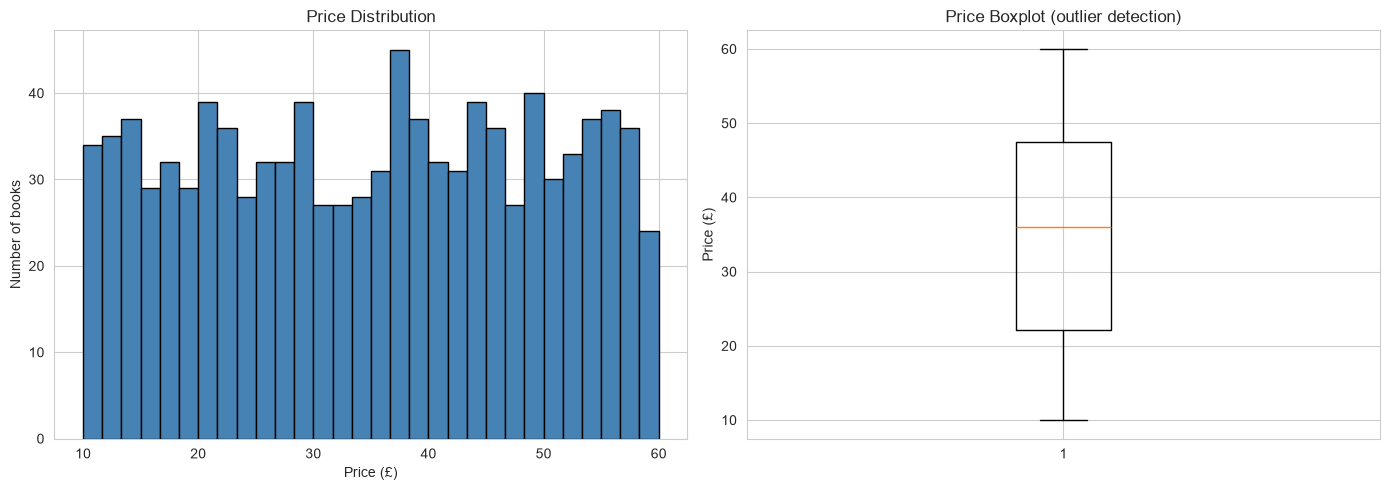

In [3]:
print("Price statistics:")
print(df["price"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["price"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of books")

# Boxplot
axes[1].boxplot(df["price"], vert=True)
axes[1].set_title("Price Boxplot (outlier detection)")
axes[1].set_ylabel("Price (£)")

plt.tight_layout()
plt.show()

Average price by rating:
             mean  median  count
rating                          
1       34.561195  34.770    226
2       34.810918  36.215    196
3       34.692020  33.780    203
4       36.093296  37.800    179
5       35.374490  36.900    196


C:\Users\Admin\AppData\Local\Temp\ipykernel_8464\4022537754.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="rating", y="price", ax=axes[0], palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipykernel_8464\4022537754.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rating", y="price", ax=axes[1], palette="viridis")


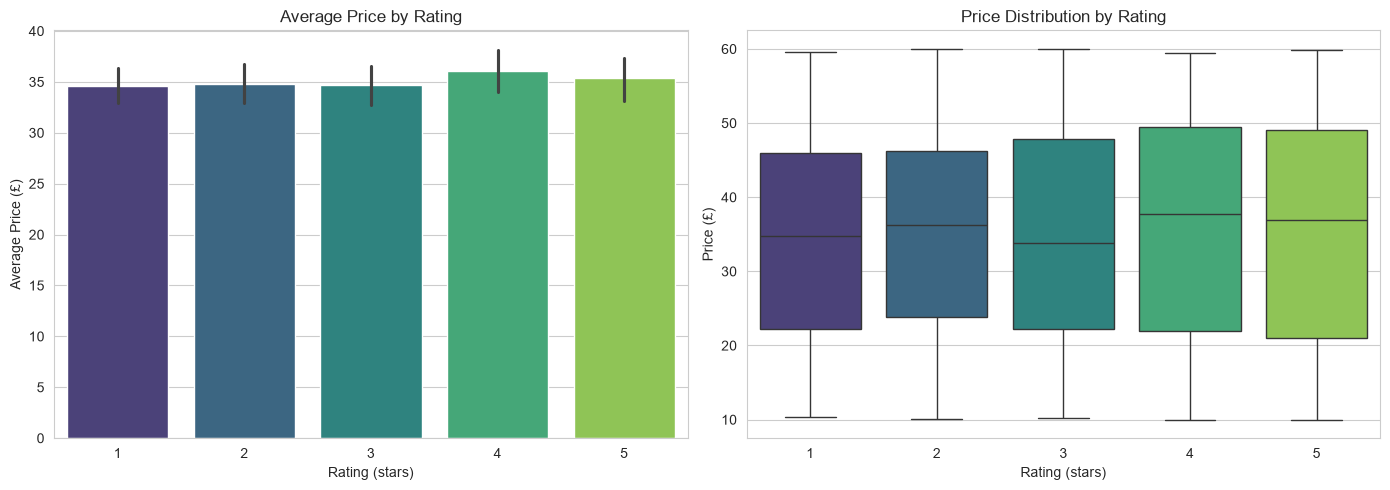


Correlation between rating and price: 0.0282


In [4]:
# Average price per rating
print("Average price by rating:")
print(df.groupby("rating")["price"].agg(["mean", "median", "count"]))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: mean price per rating
sns.barplot(data=df, x="rating", y="price", ax=axes[0], palette="viridis")
axes[0].set_title("Average Price by Rating")
axes[0].set_xlabel("Rating (stars)")
axes[0].set_ylabel("Average Price (£)")

# Boxplot: price distribution per rating
sns.boxplot(data=df, x="rating", y="price", ax=axes[1], palette="viridis")
axes[1].set_title("Price Distribution by Rating")
axes[1].set_xlabel("Rating (stars)")
axes[1].set_ylabel("Price (£)")

plt.tight_layout()
plt.show()

# Correlation
corr = df["rating"].corr(df["price"])
print(f"\nCorrelation between rating and price: {corr:.4f}")

In [5]:
# Top 10 most expensive
print("TOP 10 MOST EXPENSIVE BOOKS:")
print(df.nlargest(10, "price")[["title", "price", "rating"]].to_string(index=False))

print("\nTOP 10 CHEAPEST BOOKS:")
print(df.nsmallest(10, "price")[["title", "price", "rating"]].to_string(index=False))

# Top rated books
print("\nHIGHEST RATED BOOKS (5-star, top 10 by price):")
print(df[df["rating"] == 5].nlargest(10, "price")[["title", "price"]].to_string(index=False))

TOP 10 MOST EXPENSIVE BOOKS:
                                                                                    title  price  rating
                                                       The Perfect Play (Play by Play #1)  59.99       3
                                                        Last One Home (New Beginnings #1)  59.98       3
                                                         Civilization and Its Discontents  59.95       2
                                                           The Barefoot Contessa Cookbook  59.92       5
                                                                The Diary of a Young Girl  59.90       3
                                     The Bone Hunters (Lexy Vaughan & Steven Macaulay #2)  59.71       3
Thomas Jefferson and the Tripoli Pirates: The Forgotten War That Changed American History  59.64       1
                                                            Boar Island (Anna Pigeon #19)  59.48       3
                          

Rating distribution:
rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

Percentage:
rating
1    22.6
2    19.6
3    20.3
4    17.9
5    19.6
Name: count, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_8464\2526293166.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="rating", palette="magma", ax=axes[0])


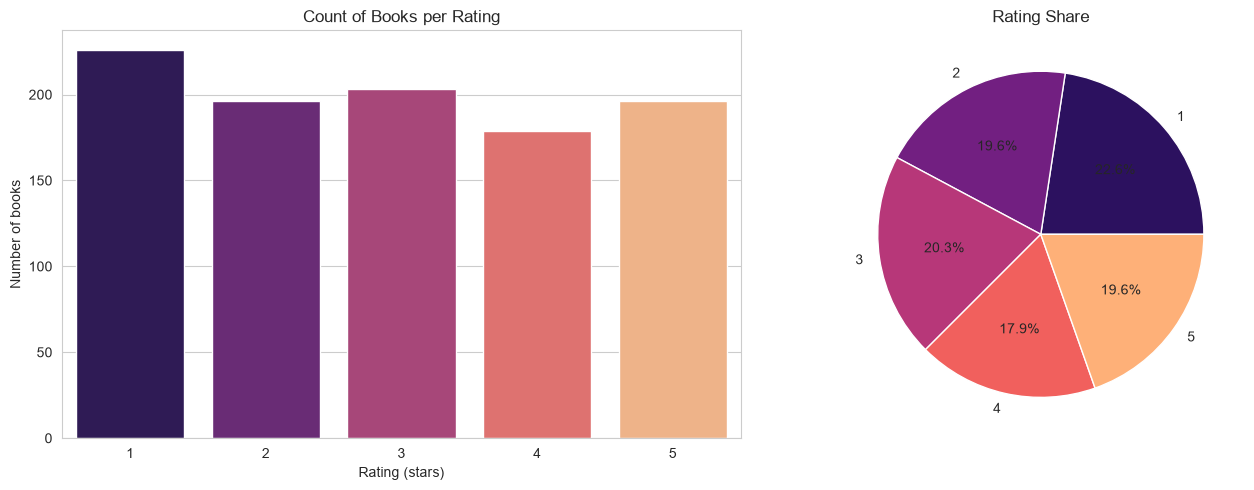

In [6]:
# Rating counts
rating_counts = df["rating"].value_counts().sort_index()
print("Rating distribution:")
print(rating_counts)
print("\nPercentage:")
print((rating_counts / len(df) * 100).round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="rating", palette="magma", ax=axes[0])
axes[0].set_title("Count of Books per Rating")
axes[0].set_xlabel("Rating (stars)")
axes[0].set_ylabel("Number of books")

axes[1].pie(rating_counts, labels=rating_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("magma", 5))
axes[1].set_title("Rating Share")

plt.tight_layout()
plt.show()

## 📊 EDA Summary

### Data Overview
- 1000 books, 4 columns, no missing values, no duplicates
- `availability` column is constant ("In stock") — no analytical value

### Key Findings

1. **Price distribution (Q1):** Prices range from £10.00 to £59.99, mean ≈ £35. Fairly uniform distribution — no dominant price tier.

2. **Rating vs price (Q2):** Correlation ≈ 0.00. Book rating is independent of price. Rejects the assumption that "better-rated = more expensive."

3. **Data quality (Q3):** `availability` has zero variance — every book is "In stock." Column dropped from further analysis.

4. **Anomalies (Q4):** No statistical outliers detected in price (boxplot shows none).

5. **Rating balance (Q5):** Ratings are almost evenly distributed across 1–5 stars (~200 books each). No rating bias.

In [8]:
# Save clean dataset for Task 3 (visualization)
df.drop(columns=["availability"]).to_csv("data/books_clean.csv", index=False)
print("✅ Saved clean dataset to data/books_clean.csv")

✅ Saved clean dataset to data/books_clean.csv
